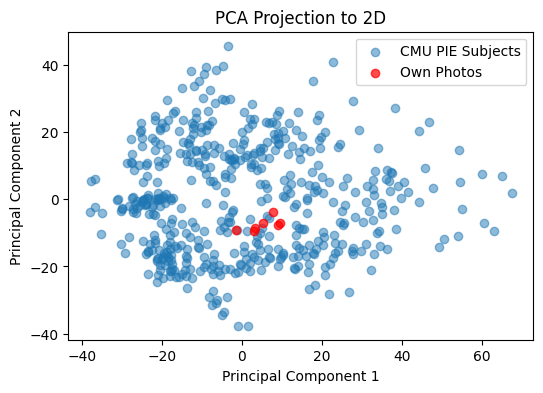

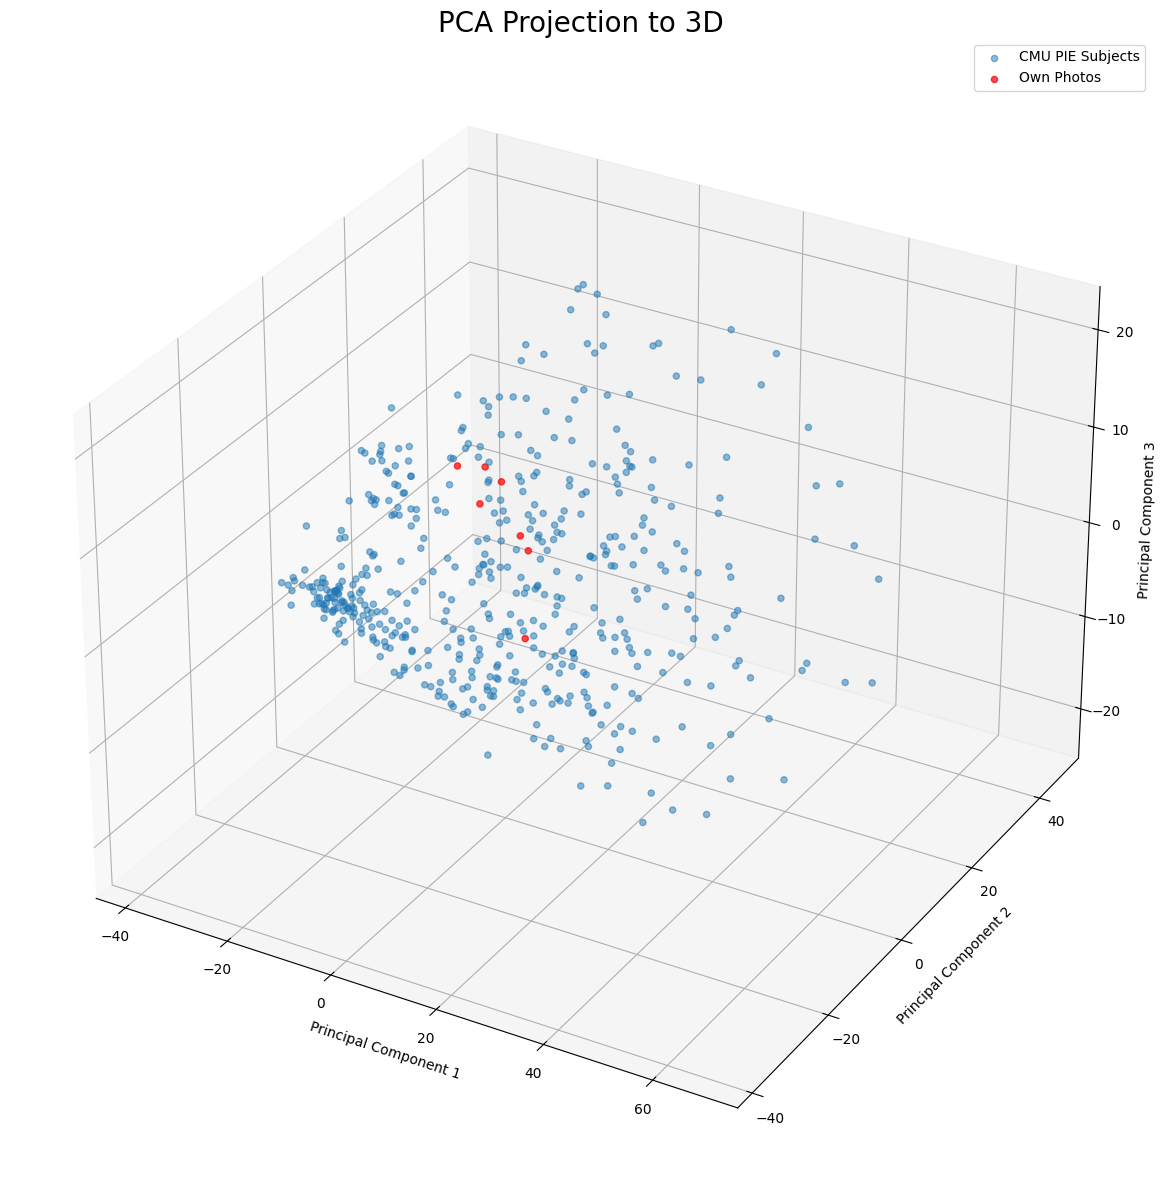

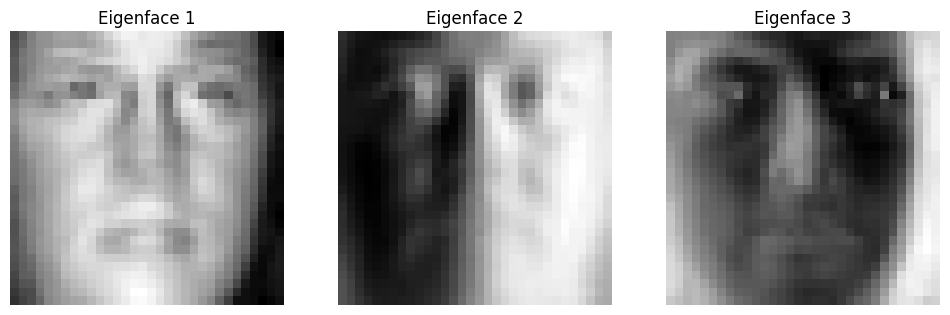

PCA with 40 components:
CMU PIE Test Accuracy: 0.9467
Own Photos Test Accuracy: 1.0000
---
PCA with 80 components:
CMU PIE Test Accuracy: 0.9616
Own Photos Test Accuracy: 1.0000
---
PCA with 200 components:
CMU PIE Test Accuracy: 0.9671
Own Photos Test Accuracy: 1.0000
---


In [2]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Function to load and preprocess images from multiple subject folders
def load_images_from_folders(main_folder, img_size=(32, 32)):
    images = []
    labels = []
    subject_id = 0

    # Iterate through the 25 folders for subjects
    for folder_name in os.listdir(main_folder):
        folder_path = os.path.join(main_folder, folder_name)
        if os.path.isdir(folder_path):
            for filename in os.listdir(folder_path):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img_resized = cv2.resize(img, img_size)
                    images.append(img_resized.flatten())
                    labels.append(subject_id)  # Label by subject
            subject_id += 1

    return np.array(images), np.array(labels)

# Function to load selfie images
def load_selfie_images(selfie_folder, img_size=(32, 32)):
    images = []
    labels = []
    for filename in os.listdir(selfie_folder):
        img_path = os.path.join(selfie_folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_resized = cv2.resize(img, img_size)
            images.append(img_resized.flatten())
            labels.append(25)  # Label all selfies as class 25
    return np.array(images), np.array(labels)

# Load images from the 25 subject folders
X_cmu, y_cmu = load_images_from_folders('C:/Users/Administrator/Desktop/EE5907/Qi Ninghan/data')

# Load selfie images
X_selfie, y_selfie = load_selfie_images('C:/Users/Administrator/Desktop/EE5907/Qi Ninghan/selfie')

# Split 25 subjects' dataset into training (70%) and testing (30%)
X_train_cmu, X_test_cmu, y_train_cmu, y_test_cmu = train_test_split(
    X_cmu, y_cmu, test_size=0.3, random_state=67
)

# Split selfie images with stratified sampling
X_train_selfie, X_test_selfie, y_train_selfie, y_test_selfie = train_test_split(
    X_selfie, y_selfie, test_size=0.3, random_state=67
)

# Combine subjects' and selfies' training sets and testing sets
X_train = np.vstack((X_train_cmu, X_train_selfie))
y_train = np.hstack((y_train_cmu, y_train_selfie))

X_test = np.vstack((X_test_cmu, X_test_selfie))
y_test = np.hstack((y_test_cmu, y_test_selfie))

# Standardize the training and testing data
scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.transform(X_test)

# Randomly sample 500 images from the CMU PIE training set and selfies
N_selfie_train = X_train_selfie.shape[0]
N_sample_cmu = 500 - N_selfie_train

indices_cmu = np.random.choice(X_train_cmu.shape[0], N_sample_cmu, replace=False)
X_sample_cmu = X_train_cmu[indices_cmu]
y_sample_cmu = y_train_cmu[indices_cmu]

X_sample_selfie = X_train_selfie
y_sample_selfie = y_train_selfie

X_sample = np.vstack((X_sample_cmu, X_sample_selfie))
y_sample = np.hstack((y_sample_cmu, y_sample_selfie))

# Standardize the sampled data
X_sample_standardized = scaler.transform(X_sample)

# Apply PCA to reduce dimensionality to 2
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_sample_standardized)

# Apply PCA to reduce dimensionality to 3
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_sample_standardized)

# Visualize the projected data vector in 2D plot
is_selfie = (y_sample == 25)

plt.figure(figsize=(6, 4))
plt.scatter(X_pca_2[~is_selfie, 0], X_pca_2[~is_selfie, 1], label='CMU PIE Subjects', alpha=0.5)
plt.scatter(X_pca_2[is_selfie, 0], X_pca_2[is_selfie, 1], label='Own Photos', color='red', alpha=0.7)
plt.legend()
plt.title('PCA Projection to 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Plotting the data
ax.scatter(X_pca_3[~is_selfie, 0], X_pca_3[~is_selfie, 1], X_pca_3[~is_selfie, 2],
           label='CMU PIE Subjects', alpha=0.5)
ax.scatter(X_pca_3[is_selfie, 0], X_pca_3[is_selfie, 1], X_pca_3[is_selfie, 2],
           label='Own Photos', color='red', alpha=0.7)

ax.set_title('PCA Projection to 3D', pad=0, fontsize=20)
ax.set_xlabel('Principal Component 1', labelpad=5)
ax.set_ylabel('Principal Component 2', labelpad=5)
ax.set_zlabel('Principal Component 3', labelpad=5)
ax.legend()
plt.tight_layout()
plt.show()

# Visualize the corresponding 3 eigenfaces
eigenfaces = pca_3.components_

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
for i, ax in enumerate(axes):
    eigenface = eigenfaces[i].reshape(32, 32)
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f'Eigenface {i+1}')
    ax.axis('off')
plt.show()

# Apply PCA to reduce the dimensionality to 40, 80, and 200
n_components_list = [40, 80, 200]

for n_components in n_components_list:
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_standardized)
    X_test_pca = pca.transform(X_test_standardized)
    
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train_pca, y_train)
    
    y_pred = knn.predict(X_test_pca)
    
    is_selfie_test = (y_test == 25)
    cmu_accuracy = accuracy_score(y_test[~is_selfie_test], y_pred[~is_selfie_test])
    selfie_accuracy = accuracy_score(y_test[is_selfie_test], y_pred[is_selfie_test])
    
    print(f'PCA with {n_components} components:')
    print(f'CMU PIE Test Accuracy: {cmu_accuracy:.4f}')
    print(f'Own Photos Test Accuracy: {selfie_accuracy:.4f}')
    print('---')
